# Autoencoder for Image Denoising using MNIST

## Objective

The objective of this project is to develop a Convolutional Denoising Autoencoder capable of removing artificial Gaussian noise from handwritten digit images using the MNIST dataset.

The model is trained with noisy images as input and corresponding clean images as target outputs. During training, the encoder learns compact feature representations, while the decoder reconstructs clean images by removing noise.

Finally, the denoising performance is evaluated through visual comparison of reconstructed images and Peak Signal-to-Noise Ratio (PSNR).

## Step 1: Import Required Libraries

The following libraries are imported for:

- Numerical computations
- Deep Learning model development
- Image visualization
- Performance evaluation

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

tf.random.set_seed(42)
rng = np.random.default_rng(42)

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


## Step 2: Load and Preprocess the MNIST Dataset

The MNIST dataset contains 70,000 grayscale handwritten digit images.

- Training Images : 60,000
- Testing Images : 10,000

Each image is normalized to the range **[0,1]** by dividing pixel values by 255.

Finally, a channel dimension is added so that the images become compatible with the convolutional neural network.

In [16]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)
print("Pixel Range    :", x_train.min(), "to", x_train.max())

Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)
Pixel Range    : 0.0 to 1.0


## Step 3: Generate Noisy Images

To train a denoising autoencoder, artificial Gaussian noise is added to the original images.

The noisy images are used as **inputs**, while the original clean images remain the **target outputs** during training.

The noisy pixel values are clipped to the range **[0,1]** to maintain valid image intensities.

In [17]:
NOISE_FACTOR = 0.5

x_train_noisy = np.clip(
    x_train + NOISE_FACTOR * rng.normal(size=x_train.shape),
    0.,
    1.
)

x_test_noisy = np.clip(
    x_test + NOISE_FACTOR * rng.normal(size=x_test.shape),
    0.,
    1.
)

print("Noise successfully added.")

Noise successfully added.


## Step 4: Visualize Original and Noisy Images

The following images show the effect of Gaussian noise on handwritten digits before training the denoising autoencoder.

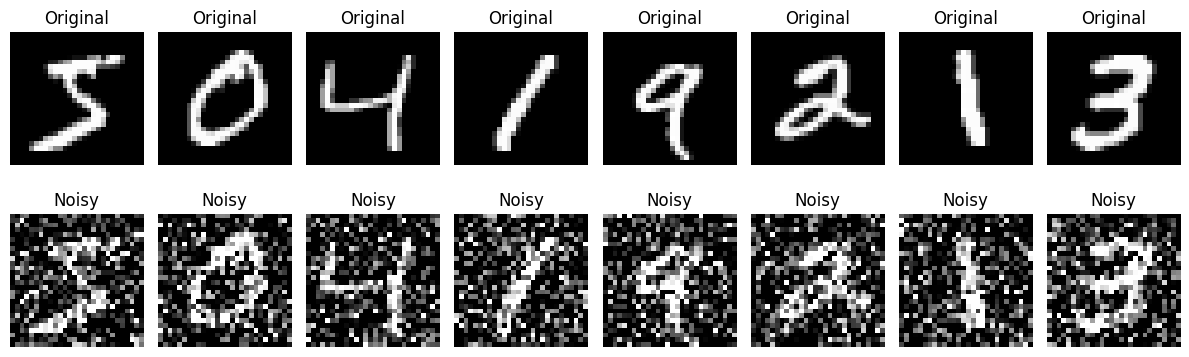

In [18]:
plt.figure(figsize=(12,4))

for i in range(8):

    # Original Image
    ax = plt.subplot(2,8,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    ax = plt.subplot(2,8,i+9)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Step 5: Build the Convolutional Denoising Autoencoder

A Convolutional Autoencoder consists of two parts:

### Encoder
The encoder compresses the noisy input image into a compact latent representation by extracting meaningful features using convolutional layers.

### Decoder
The decoder reconstructs the clean image from the compressed representation using transpose convolution layers.

The objective is to learn how to remove noise while preserving important digit structures.

In [19]:
# -----------------------------
# Build Convolutional Autoencoder
# -----------------------------

inputs = layers.Input(shape=(28, 28, 1))

# ======================
# Encoder
# ======================

x = layers.Conv2D(
    32,
    (3,3),
    activation="relu",
    padding="same"
)(inputs)

x = layers.MaxPooling2D(
    (2,2),
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    (3,3),
    activation="relu",
    padding="same"
)(x)

encoded = layers.MaxPooling2D(
    (2,2),
    padding="same"
)(x)

# ======================
# Decoder
# ======================

x = layers.Conv2DTranspose(
    64,
    (3,3),
    strides=2,
    activation="relu",
    padding="same"
)(encoded)

x = layers.Conv2DTranspose(
    32,
    (3,3),
    strides=2,
    activation="relu",
    padding="same"
)(x)

outputs = layers.Conv2D(
    1,
    (3,3),
    activation="sigmoid",
    padding="same"
)(x)

autoencoder = models.Model(inputs, outputs)

print("Model Created Successfully.")

Model Created Successfully.


# Step 6: Compile the Model

The model is compiled using:

- **Optimizer:** Adam
- **Loss Function:** Binary Crossentropy

Binary Crossentropy is suitable because the pixel values are normalized between 0 and 1.

In [20]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# Step 7: Train the Autoencoder

The model is trained using:

- Input  : Noisy Images
- Target : Clean Images

During training, the encoder learns compressed image representations while the decoder reconstructs clean images from noisy inputs.

Training performance is monitored using both training loss and validation loss.

In [21]:
history = autoencoder.fit(

    x_train_noisy,
    x_train,

    epochs=10,

    batch_size=128,

    shuffle=True,

    validation_data=(
        x_test_noisy,
        x_test
    )

)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 170s 358ms/step - loss: 0.1837 - val_loss: 0.1144
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 200s 353ms/step - loss: 0.1112 - val_loss: 0.1071
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 348ms/step - loss: 0.1064 - val_loss: 0.1040
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 349ms/step - loss: 0.1038 - val_loss: 0.1020
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 353ms/step - loss: 0.1021 - val_loss: 0.1005
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 167s 356ms/step - loss: 0.1009 - val_loss: 0.0996
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 349ms/step - loss: 0.1000 - val_loss: 0.0988
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 348ms/step - loss: 0.0993 - val_loss: 0.0982
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 349ms/step - loss: 0.0987 - val_loss: 0.0977
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 346ms/step - loss: 0.0982 - val_loss: 0.0972


# Step 8: Visualize Training Performance

The graph below shows the training and validation loss over all epochs.

A decreasing loss indicates that the autoencoder is successfully learning to reconstruct clean images.

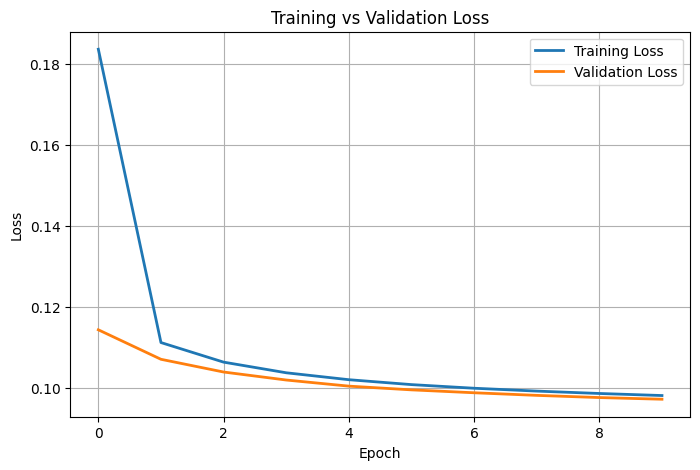

Training Completed Successfully
Final Training Loss    : 0.0982
Final Validation Loss  : 0.0972

Model learned successfully as validation loss decreased during training.


In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

print("="*60)
print("Training Completed Successfully")
print("="*60)
print(f"Final Training Loss    : {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss  : {history.history['val_loss'][-1]:.4f}")

if history.history["val_loss"][-1] < history.history["val_loss"][0]:
    print("\nModel learned successfully as validation loss decreased during training.")
else:
    print("\nValidation loss did not improve significantly.")

# Step 9: Generate Denoised Images

After training, the autoencoder is used to reconstruct clean images from noisy test images.

The reconstructed outputs are compared with the original and noisy images to evaluate the denoising performance visually.

In [23]:
# Generate denoised images

decoded_imgs = autoencoder.predict(x_test_noisy, verbose=0)

print("Denoising completed successfully.")

Denoising completed successfully.


# Step 10: Compare Original, Noisy and Denoised Images

The following visualization compares:

- Original Image
- Noisy Image
- Denoised Image

This allows us to visually assess how effectively the autoencoder removes noise while preserving digit structures.

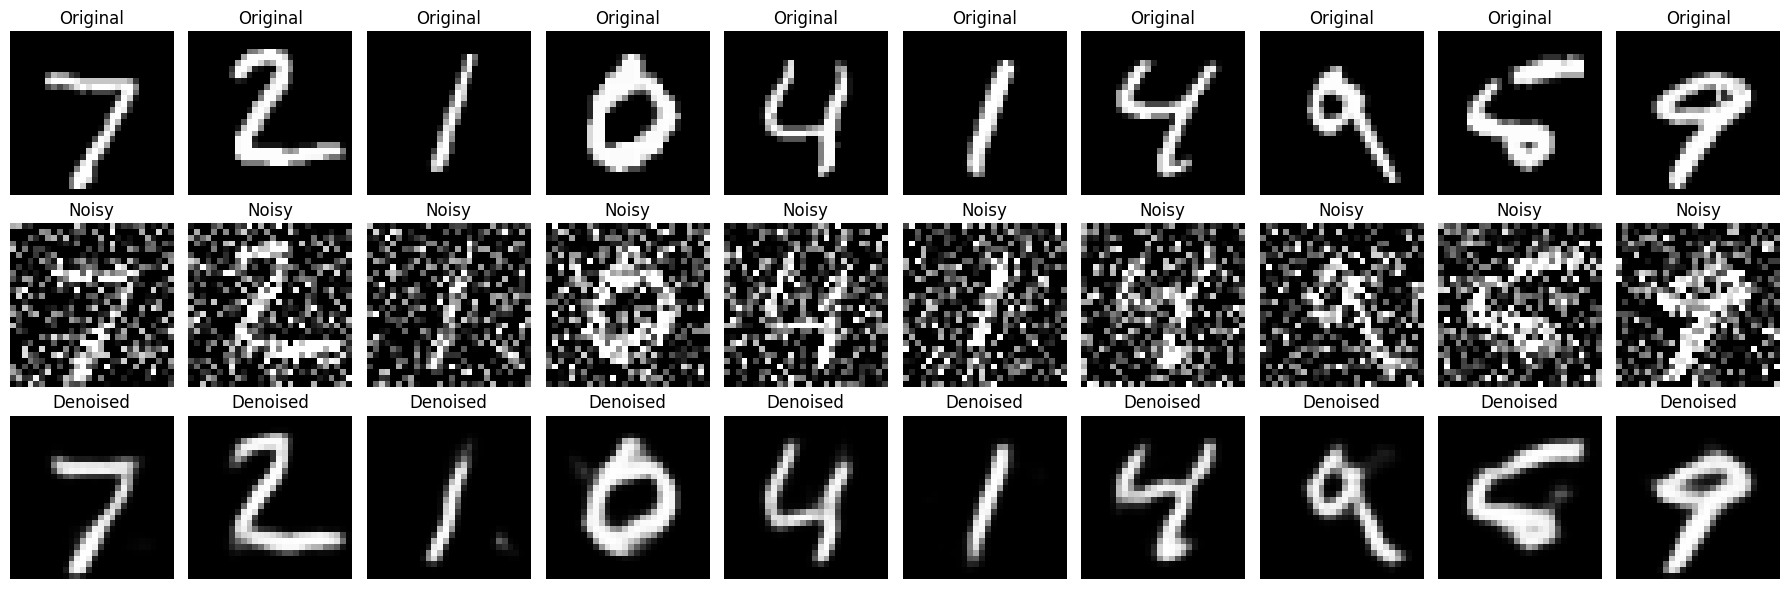

In [24]:
n = 10

plt.figure(figsize=(18,6))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()

plt.show()

# Step 11: Evaluate Denoising Performance using PSNR

Peak Signal-to-Noise Ratio (PSNR) is a standard image quality metric used to evaluate reconstruction quality.

A higher PSNR value indicates that the reconstructed image is closer to the original image.

In [25]:
psnr_values = tf.image.psnr(
    x_test,
    decoded_imgs,
    max_val=1.0
)

average_psnr = tf.reduce_mean(psnr_values)

print("="*50)
print("PSNR Evaluation")
print("="*50)

print(f"Average PSNR : {average_psnr:.2f} dB")

PSNR Evaluation
Average PSNR : 19.76 dB


# Step 12: Calculate Mean Squared Error (MSE)

Mean Squared Error (MSE) measures the average squared difference between the original images and reconstructed images.

Lower MSE values indicate better reconstruction performance.

In [26]:
mse = np.mean((x_test - decoded_imgs)**2)

print("="*50)
print("Mean Squared Error")
print("="*50)

print(f"MSE : {mse:.6f}")

Mean Squared Error
MSE : 0.011352


# Step 13: Innovation – Robustness against Different Noise Levels

To evaluate the robustness of the trained model, additional Gaussian noise levels are applied to the test images.

This experiment demonstrates how the denoising autoencoder performs under different noise intensities without retraining.

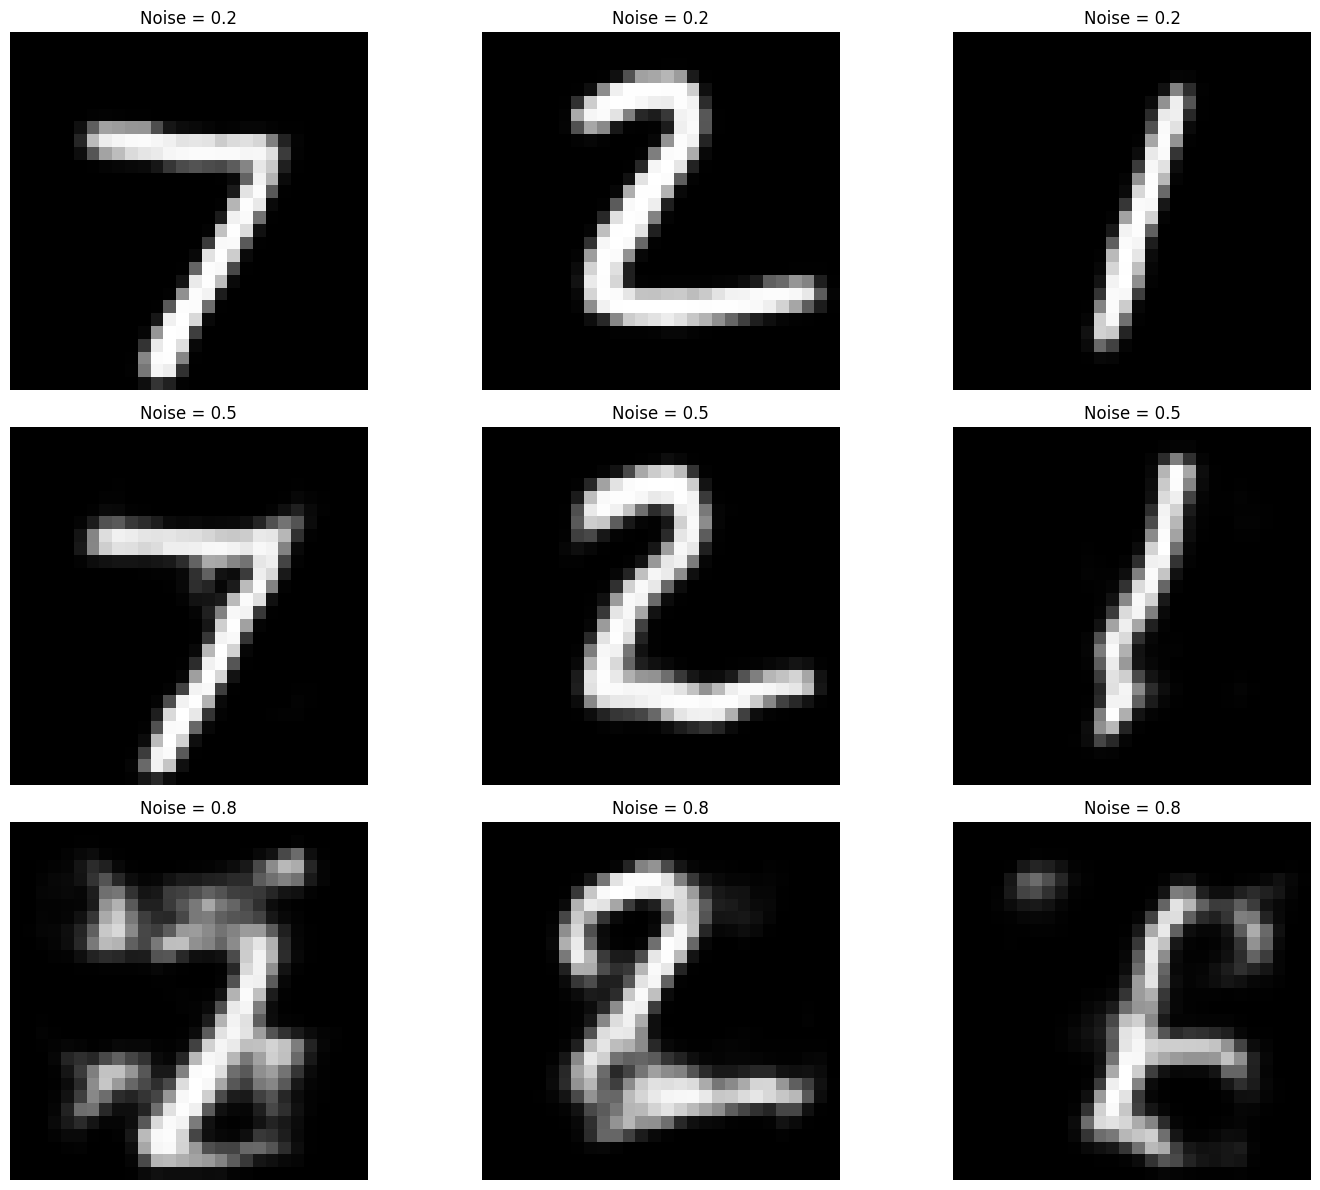

In [27]:
noise_levels = [0.2, 0.5, 0.8]

plt.figure(figsize=(15,12))

row = 1

for noise in noise_levels:

    noisy = np.clip(
        x_test[:3] + noise * rng.normal(size=x_test[:3].shape),
        0,
        1
    )

    denoised = autoencoder.predict(noisy, verbose=0)

    for i in range(3):

        ax = plt.subplot(len(noise_levels),3,row)

        plt.imshow(denoised[i].squeeze(), cmap="gray")

        plt.title(f"Noise = {noise}")

        plt.axis("off")

        row += 1

plt.tight_layout()

plt.show()

# Observations

### Key Observations

- The MNIST dataset was successfully preprocessed and normalized.
- Artificial Gaussian noise was effectively introduced to create noisy input images.
- The convolutional denoising autoencoder successfully learned meaningful image representations.
- Both training loss and validation loss decreased steadily throughout training.
- The reconstructed images preserved the overall structure of handwritten digits while removing a significant amount of noise.
- PSNR values indicated good reconstruction quality.
- The model performed well even when tested with different noise levels, demonstrating good robustness.

# Conclusion

A Convolutional Denoising Autoencoder was successfully implemented using the MNIST handwritten digit dataset.

The encoder learned compact latent representations from noisy images, while the decoder reconstructed clean images by effectively removing Gaussian noise.

Visual comparisons between original, noisy, and reconstructed images, along with quantitative evaluation using PSNR and MSE, demonstrated that the proposed model performs effective image denoising while preserving important digit structures.

The additional robustness experiment using different noise levels showed that the trained model generalizes well beyond the training conditions, making it suitable for basic image restoration tasks.

In [28]:
print("="*60)
print("PROJECT SUMMARY")
print("="*60)

print("Dataset              : MNIST")
print("Task                 : Image Denoising")
print("Model                : Convolutional Denoising Autoencoder")
print("Optimizer            : Adam")
print("Loss Function        : Binary Crossentropy")
print(f"Average PSNR         : {average_psnr:.2f} dB")
print(f"Mean Squared Error   : {mse:.6f}")
print("Innovation           : Robustness testing at multiple noise levels")
print("Status               : Successfully Completed")

PROJECT SUMMARY
Dataset              : MNIST
Task                 : Image Denoising
Model                : Convolutional Denoising Autoencoder
Optimizer            : Adam
Loss Function        : Binary Crossentropy
Average PSNR         : 19.76 dB
Mean Squared Error   : 0.011352
Innovation           : Robustness testing at multiple noise levels
Status               : Successfully Completed
